目前使用的特徵欄位有： ['proto', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max']
正在訓練模型中...請稍候...

--- 模型評估報告 ---
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        22
           1       1.00      1.00      1.00    146719

    accuracy                           1.00    146741
   macro avg       0.97      0.93      0.95    146741
weighted avg       1.00      1.00      1.00    146741



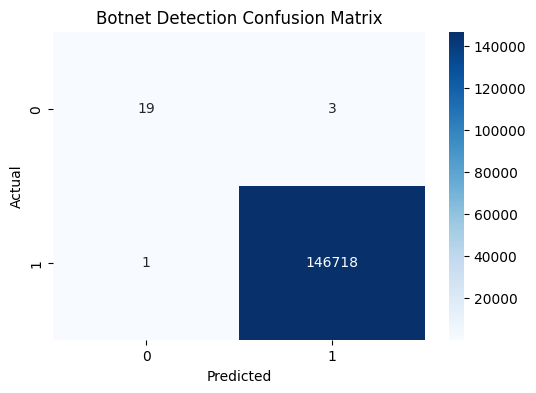

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 讀取資料 (請確保檔名正確)
# 加上資料夾路徑
df = pd.read_csv('archive/UNSW_2018_IoT_Botnet_Final_10_best_Testing.csv')

# 2. 簡單資料處理：將類別文字 (proto) 轉為數字
if 'proto' in df.columns:
    df['proto'] = pd.factorize(df['proto'])[0]

# 注意：'state_number' 已經是數字了，不需要處理

# 3. 定義 X (特徵) 與 y (標籤)
# 我們拿掉所有「非特徵」的欄位（如 ID、IP、時間、分類名稱）
drop_cols = ['pkSeqID', 'saddr', 'daddr', 'sport', 'dport', 'attack', 'category', 'subcategory']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['attack']

print("目前使用的特徵欄位有：", X.columns.tolist())

# 4. 切分訓練集與測試集 (80% 訓練, 20% 驗證)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 建立並訓練隨機森林模型
print("正在訓練模型中...請稍候...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. 評估模型準確率
y_pred = model.predict(X_test)
print("\n--- 模型評估報告 ---")
print(classification_report(y_test, y_pred))

# 7. 畫出混淆矩陣 (Confusion Matrix)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Botnet Detection Confusion Matrix')
plt.show()

In [3]:
# 看看這份檔案到底有哪些欄位名稱
print(df.columns.tolist())

['pkSeqID', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'seq', 'stddev', 'N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP', 'drate', 'srate', 'max', 'attack', 'category', 'subcategory']
